# Compare the current SciPy and Pyomo joint-control optimizers

This tutorial reproduces the historical $A_1 \times K_C$ experiment in which both shelf temperature and chamber pressure are released. It uses the physics and APIs on current `main`, comparing the legacy sequential SciPy optimizer with an equivalent rate-unlimited, free-final-time Pyomo.DAE model transcribed by backward finite differences and LAGRANGE-RADAU orthogonal collocation. The headline comparison gives both DAE transformations the same number of transcription points.

The notebook then asks a separate implementability question. It fixes realistic initial control values and limits pressure and shelf-temperature movement between transcription nodes. Keeping the exact reproduction and this extension separate prevents actuator assumptions from silently changing the historical objective comparison.

## What is held equivalent?

| SciPy workflow | Rate-unlimited Pyomo.DAE workflow |
| --- | --- |
| Sequentially minimize $P_{ch}-P_{sub}$, maximizing rate at each cake state | Simultaneously minimize free final drying time |
| Advance the one cake-length ODE explicitly | Transcribe the same ODE with Pyomo.DAE |
| Stop at 100% dried | Constrain the terminal state to 100% dried |
| Optimize shelf temperature from -45 to 120 °C and chamber pressure from 50 to 500 mTorr | Optimize the same two controls with the same bounds |
| No actuator-rate constraints | No actuator-rate constraints |

With one monotone differential state and no intertemporal control penalty, maximizing sublimation rate at every state minimizes completion time. The comparison therefore uses final drying time as the common process objective. Finite differences and collocation are alternative algebraic reformulations of the same DAE, not different physical models.

This exact legacy formulation returns an idealized operating policy indexed by cake state. It should not be read as a physically implementable control trajectory when a control moves immediately to a bound. The rate-limited extension later in the notebook is a different optimization problem and is reported separately.

## Optional solver setup

Run this notebook from the repository root after installing the optional stack:

\`\`\`bash
python -m pip install -e ".[dev,pyomo]"
idaes get-extensions --extra petsc
export PATH="$HOME/.idaes/bin:$PATH"
jupyter lab docs/examples/current_main_joint_optimizer_comparison.ipynb
\`\`\`

A conda-forge IPOPT installation can be used instead. The full default grid takes several minutes because every SciPy reference advances with the configured fine time step and timing is repeated.


In [1]:
# Papermill parameters: CI overrides these with a small smoke case.
a1_values = [16.0, 18.0, 20.0]
kc_values = [2.75e-4, 3.30e-4, 4.00e-4]
scipy_dt = 0.01
scipy_dt_values = [0.1, 0.05, 0.02, 0.01]
point_budget = 25
ncp = 3
final_dried_fraction = 1.0
timing_repeats = 3
sensitivity_point_budgets = [25, 49, 73]
pressure_lower_bound_values_torr = [0.05, 0.075, 0.10, 0.15, 0.20]
implementability_point_budget = 97
initial_pressure_torr = 0.15
initial_shelf_temperature_c = -35.0
pressure_ramp_rate_torr_hr = 0.6
shelf_temperature_ramp_rate_c_hr = 60.0
constraint_tolerance = 1.0e-4
scipy_temperature_tolerance_c = 0.5
save_results = False
results_dir = "benchmarks/results/current_main_joint_comparison"

In [2]:
import json
import platform
import subprocess
from importlib.metadata import version
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pyomo
import scipy

from examples.current_main_joint_optimizer_comparison import (
    comparison_inputs,
    matched_nfe_for_point_budget,
    run_case_comparison,
    run_discretization_sensitivity,
    run_pyomo_dae,
    run_scipy_reference,
    trajectory_constraint_diagnostics,
)

In [3]:
try:
    git_revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    git_revision = "unavailable"

environment = {
    "git_revision": git_revision,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "lyopronto": version("lyopronto"),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "pyomo": pyomo.__version__,
    "matplotlib": matplotlib.__version__,
}
environment


{'git_revision': '77e5459c98b9d1c0529160f525ce1a29252d8b95',
 'python': '3.13.5',
 'platform': 'Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'lyopronto': '1.1.0',
 'numpy': '2.5.0',
 'scipy': '1.17.1',
 'pyomo': '6.9.5',
 'matplotlib': '3.10.9'}

## Experimental protocol

For each $(A_1, K_C)$ pair, the helper performs three equivalent runs:

1. Run \`opt_Pch_Tsh.dry\` to 100% dried using the configured sequential step.
2. Solve the free-final-time joint Pyomo.DAE model with \`dae.finite_difference\` and the \`BACKWARD\` scheme.
3. Solve the same model with \`dae.collocation\` and the \`LAGRANGE-RADAU\` scheme.
4. Require every workflow to reach the same configured terminal dried fraction.
5. Compare the final-time objectives directly and report median end-to-end wall times.

The default timing is a cold-start, workflow-level comparison: model construction and IPOPT solve are included, while an untimed warm-up removes one-time import and executable startup costs. Collocation uses \`nfe * ncp + 1\` time points, whereas finite differences use \`nfe + 1\`. Separate \`nfe\` values give both DAE transformations exactly \`point_budget\` time points. Scalar-variable and active-constraint counts are also reported because equal point counts are only a first approximation to equal NLP size.


In [4]:
# Pay one-time Pyomo/IPOPT initialization before collecting timings.
for method in ("finite_difference", "collocation"):
    warmup = run_pyomo_dae(
        a1_values[0], kc_values[0], discretization=method, nfe=4, ncp=ncp
    )
    assert warmup.success, (method, warmup.solver_status, warmup.termination_condition)


In [5]:
finite_difference_nfe, collocation_nfe = matched_nfe_for_point_budget(
    point_budget, ncp
)
print(
    f"Matched DAE budget: {point_budget} points "
    f"(FD nfe={finite_difference_nfe}; "
    f"collocation nfe={collocation_nfe}, ncp={ncp})"
)

comparisons = []
for a1 in a1_values:
    for kc in kc_values:
        print(f"Running A1={a1:g}, KC={kc:.2e} ...")
        comparisons.append(
            run_case_comparison(
                a1,
                kc,
                scipy_dt=scipy_dt,
                finite_difference_nfe=finite_difference_nfe,
                collocation_nfe=collocation_nfe,
                ncp=ncp,
                final_dried_fraction=final_dried_fraction,
                timing_repeats=timing_repeats,
            )
        )

case_by_parameter = {(case.a1, case.kc): case for case in comparisons}
print(f"Completed {len(comparisons)} grid cases.")


Matched DAE budget: 25 points (FD nfe=24; collocation nfe=8, ncp=3)
Running A1=16, KC=2.75e-04 ...


Running A1=16, KC=3.30e-04 ...


Running A1=16, KC=4.00e-04 ...


Running A1=18, KC=2.75e-04 ...


Running A1=18, KC=3.30e-04 ...


Running A1=18, KC=4.00e-04 ...


Running A1=20, KC=2.75e-04 ...


Running A1=20, KC=3.30e-04 ...


Running A1=20, KC=4.00e-04 ...


Completed 9 grid cases.


In [6]:
header = (
    f"{'A1':>5} {'KC':>10} {'method':>20} {'time [h]':>10} "
    f"{'gap [%]':>10} {'wall [s]':>11} {'speedup':>10} "
    f"{'points/steps':>12} {'variables':>10} {'constraints':>12} "
    f"{'iterations':>11}"
)
print(header)
print("-" * len(header))
for case in comparisons:
    print(
        f"{case.a1:5.1f} {case.kc:10.2e} {'SciPy':>20} "
        f"{case.scipy_objective_time_hr:10.4f} {0.0:10.3f} "
        f"{case.scipy_wall_median_s:11.3f} {1.0:10.1f} "
        f"{case.scipy_trajectory.shape[0]:12d} "
        f"{'-':>10} {'-':>12} {'-':>11}"
    )
    rows = [
        (
            "finite difference",
            case.finite_difference_objective_time_hr,
            case.finite_difference_objective_gap_percent,
            case.finite_difference_wall_median_s,
            case.finite_difference_speedup,
            case.finite_difference_trajectory,
            case.finite_difference_n_variables,
            case.finite_difference_n_constraints,
            case.finite_difference_solver_iterations,
        ),
        (
            "collocation",
            case.collocation_objective_time_hr,
            case.collocation_objective_gap_percent,
            case.collocation_wall_median_s,
            case.collocation_speedup,
            case.collocation_trajectory,
            case.collocation_n_variables,
            case.collocation_n_constraints,
            case.collocation_solver_iterations,
        ),
    ]
    for method, objective, gap, wall, speedup, table, nvars, ncons, iterations in rows:
        iteration_text = "-" if iterations is None else str(iterations)
        print(
            f"{case.a1:5.1f} {case.kc:10.2e} {method:>20} "
            f"{objective:10.4f} {gap:10.3f} {wall:11.3f} "
            f"{speedup:10.1f} {table.shape[0]:12d} {nvars:10d} "
            f"{ncons:12d} {iteration_text:>11}"
        )


   A1         KC               method   time [h]    gap [%]    wall [s]    speedup points/steps  variables  constraints  iterations
-----------------------------------------------------------------------------------------------------------------------------------
 16.0   2.75e-04                SciPy    10.7518      0.000       4.160        1.0         1077          -            -           -
 16.0   2.75e-04    finite difference    11.1255      3.475       0.063       66.1           25        251          253           -
 16.0   2.75e-04          collocation    10.7608      0.083       0.047       88.9           25        251          253           -
 16.0   3.30e-04                SciPy    10.7518      0.000       4.116        1.0         1077          -            -           -
 16.0   3.30e-04    finite difference    11.1255      3.475       0.043       95.8           25        251          253           -
 16.0   3.30e-04          collocation    10.7608      0.083       0.044     

## Validate before interpreting

An `optimal` solver termination is not sufficient by itself. The experiment independently checks every exported SciPy and Pyomo table for completion, finite seven-column output, both control bounds, the product-temperature limit, and equipment capability. The SciPy product-temperature check allows 0.5 °C for SLSQP and sequential-step tolerances; the simultaneous Pyomo tables use the tighter model residual tolerance. Legacy output pressure remains in mTorr and percent dried remains on a 0–100 scale.

In [7]:
diagnostic_rows = []
for case in comparisons:
    data = comparison_inputs(case.a1, case.kc)
    method_tables = [
        ("SciPy", case.scipy_trajectory, scipy_temperature_tolerance_c),
        (
            "finite difference",
            case.finite_difference_trajectory,
            constraint_tolerance,
        ),
        (
            "collocation",
            case.collocation_trajectory,
            constraint_tolerance,
        ),
    ]
    assert case.finite_difference_trajectory.shape == (point_budget, 7)
    assert case.collocation_trajectory.shape == (point_budget, 7)
    for method, table, temperature_tolerance in method_tables:
        diagnostics = trajectory_constraint_diagnostics(table, data)
        assert table.shape[1] == 7
        assert diagnostics["final_dried_percent"] >= (
            100.0 * final_dried_fraction - 1.0e-3
        )
        assert (
            diagnostics["product_temperature_violation_c"]
            <= temperature_tolerance
        )
        assert diagnostics["pressure_lower_violation_mtorr"] <= 1.0e-3
        assert diagnostics["pressure_upper_violation_mtorr"] <= 1.0e-3
        assert diagnostics["shelf_lower_violation_c"] <= constraint_tolerance
        assert diagnostics["shelf_upper_violation_c"] <= constraint_tolerance
        assert diagnostics["minimum_equipment_margin_kg_hr"] >= -1.0e-6
        diagnostic_rows.append(
            {
                "A1": case.a1,
                "KC": case.kc,
                "method": method,
                **diagnostics,
            }
        )
    assert case.finite_difference_max_constraint_violation <= constraint_tolerance
    assert case.collocation_max_constraint_violation <= constraint_tolerance

print(
    f"{'method':>20} {'max Tbot violation [°C]':>25} "
    f"{'min capacity margin [kg/hr]':>29} {'mean Pmin fraction':>20}"
)
for method in ("SciPy", "finite difference", "collocation"):
    rows = [row for row in diagnostic_rows if row["method"] == method]
    print(
        f"{method:>20} "
        f"{max(row['product_temperature_violation_c'] for row in rows):25.3e} "
        f"{min(row['minimum_equipment_margin_kg_hr'] for row in rows):29.3e} "
        f"{np.mean([row['pressure_lower_bound_fraction'] for row in rows]):20.3f}"
    )

              method   max Tbot violation [°C]   min capacity margin [kg/hr]   mean Pmin fraction
               SciPy                 1.012e-10                     1.678e-01                1.000
   finite difference                 2.498e-07                     2.294e-01                1.000
         collocation                 2.499e-07                     2.084e-01                1.000


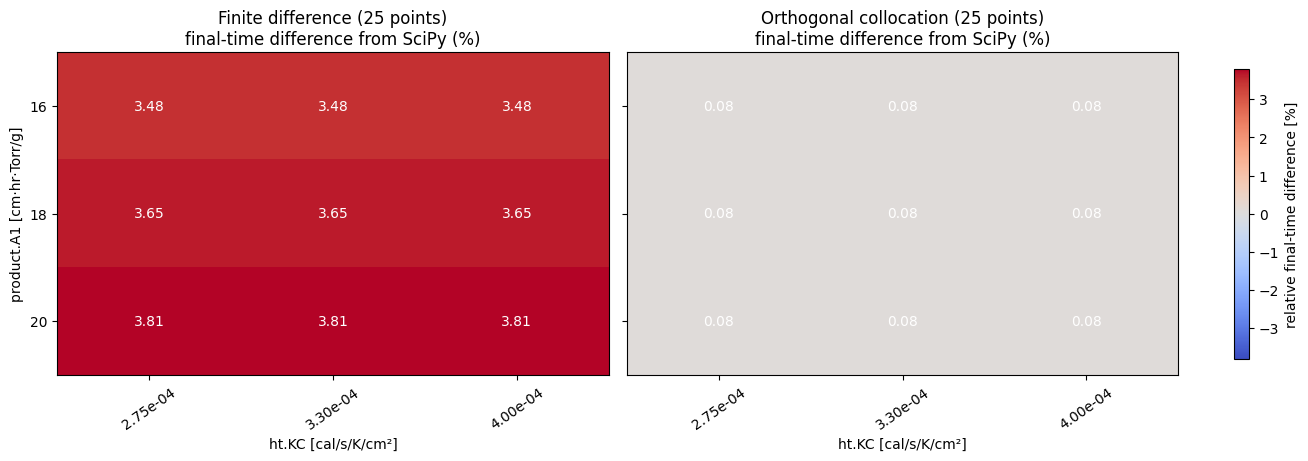

In [8]:
def matrix_for(attribute):
    return np.array(
        [
            [
                getattr(
                    case_by_parameter[(float(a1), float(kc))],
                    attribute,
                )
                for kc in kc_values
            ]
            for a1 in a1_values
        ],
        dtype=float,
    )


def annotate_heatmap(ax, values, fmt):
    threshold = 0.55 * np.nanmax(np.abs(values))
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            color = "white" if abs(values[row, col]) > threshold else "black"
            ax.text(
                col,
                row,
                format(values[row, col], fmt),
                ha="center",
                va="center",
                color=color,
            )


objective_gap_matrices = [
    (
        "Finite difference",
        matrix_for("finite_difference_objective_gap_percent"),
    ),
    (
        "Orthogonal collocation",
        matrix_for("collocation_objective_gap_percent"),
    ),
]
limit = max(
    1.0,
    max(float(np.max(np.abs(values))) for _, values in objective_gap_matrices),
)
fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.5), sharey=True, layout="constrained"
)
for ax, (label, values) in zip(axes, objective_gap_matrices):
    image = ax.imshow(
        values,
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        aspect="auto",
    )
    ax.set(
        title=(
            f"{label} ({point_budget} points)\n"
            "final-time difference from SciPy (%)"
        ),
        xlabel="ht.KC [cal/s/K/cm²]",
    )
    ax.set_xticks(
        range(len(kc_values)),
        [f"{value:.2e}" for value in kc_values],
        rotation=35,
    )
    ax.set_yticks(
        range(len(a1_values)),
        [f"{value:g}" for value in a1_values],
    )
    annotate_heatmap(ax, values, ".2f")
axes[0].set_ylabel("product.A1 [cm·hr·Torr/g]")
fig.colorbar(
    image,
    ax=axes,
    label="relative final-time difference [%]",
    shrink=0.9,
)
plt.show()


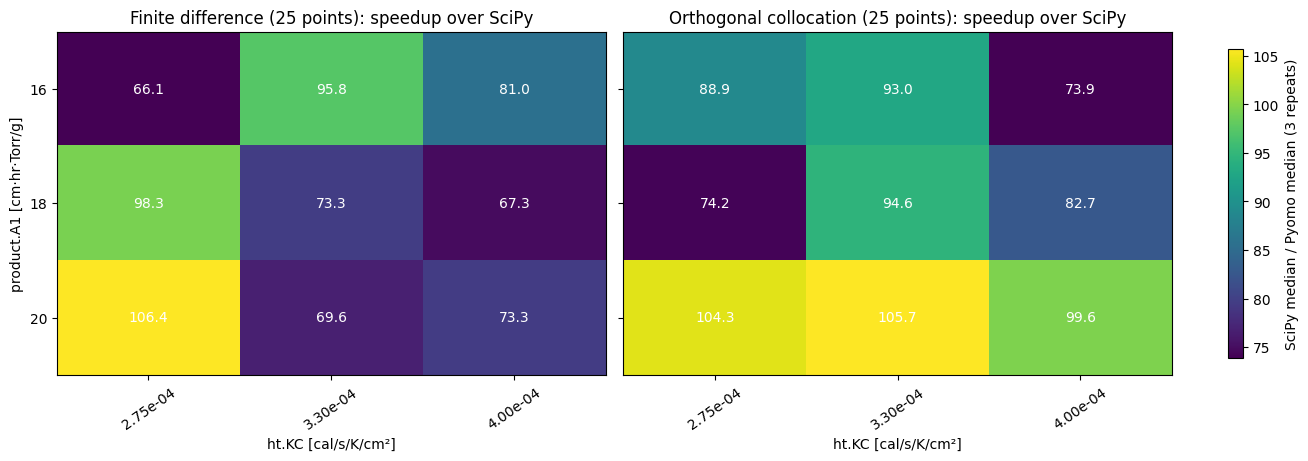

In [9]:
speedup_matrices = [
    ("Finite difference", matrix_for("finite_difference_speedup")),
    ("Orthogonal collocation", matrix_for("collocation_speedup")),
]
fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.5), sharey=True, layout="constrained"
)
for ax, (label, values) in zip(axes, speedup_matrices):
    image = ax.imshow(values, cmap="viridis", aspect="auto")
    ax.set(
        title=f"{label} ({point_budget} points): speedup over SciPy",
        xlabel="ht.KC [cal/s/K/cm²]",
    )
    ax.set_xticks(
        range(len(kc_values)),
        [f"{value:.2e}" for value in kc_values],
        rotation=35,
    )
    ax.set_yticks(
        range(len(a1_values)),
        [f"{value:g}" for value in a1_values],
    )
    annotate_heatmap(ax, values, ".1f")
axes[0].set_ylabel("product.A1 [cm·hr·Torr/g]")
fig.colorbar(
    image,
    ax=axes,
    label=f"SciPy median / Pyomo median ({timing_repeats} repeats)",
    shrink=0.9,
)
plt.show()


The speedup values are machine- and environment-dependent. They scale roughly with $1/\mathtt{scipy\_dt}$ because `opt_Pch_Tsh.dry` performs one SLSQP solve per sequential step, while changing `scipy_dt` does not change the DAE workload. SciPy step count and simultaneous NLP point count are therefore both reported but are not equivalent measures of problem size. Objective gaps, convergence trends, and physical acceptance checks are the portable numerical results.

The nearly constant 50 mTorr pressure is not evidence that pressure was accidentally fixed. Pressure is a free variable, but the optimizer drives it to its lower bound while the product-temperature constraint is active and equipment capacity has positive margin. The pressure-bound sensitivity below verifies this active-set explanation directly.

## SciPy step-size convergence

SciPy is a sequential optimizer/integrator, not a simultaneous transcription, so its number of steps should not be matched to the DAE point budget. Instead, this study quantifies the final-time reference's sensitivity to \`dt\`. The configured grid reference must be the finest value listed here. Differences comparable to the change between the two finest steps are within the SciPy reference resolution.


    dt [h]    steps     time [h]   gap from finest [%]   wall [s]
    0.1000      108     10.67333               -0.7303      0.416
    0.0500      216     10.71734               -0.3210      0.815
    0.0200      539     10.74327               -0.0797      2.063
    0.0100     1077     10.75185                0.0000      4.160


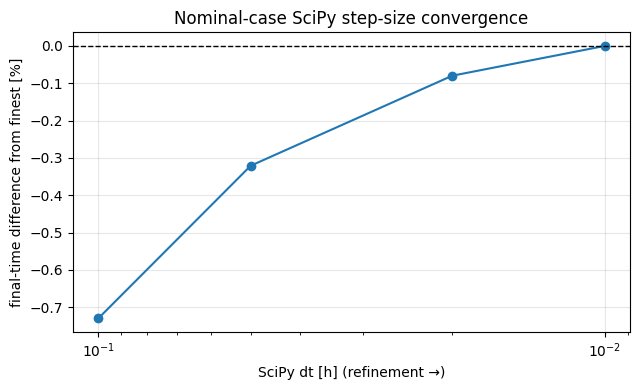

In [10]:
nominal = case_by_parameter[
    (float(a1_values[0]), float(kc_values[0]))
]
scipy_dt_values = sorted(
    {float(value) for value in scipy_dt_values},
    reverse=True,
)
assert all(value > 0.0 for value in scipy_dt_values)
assert np.isclose(scipy_dt, min(scipy_dt_values))

scipy_convergence_rows = []
for dt in scipy_dt_values:
    if np.isclose(dt, scipy_dt):
        objective_time_hr = nominal.scipy_objective_time_hr
        wall_time_s = nominal.scipy_wall_median_s
        n_steps = nominal.scipy_trajectory.shape[0]
    else:
        run = run_scipy_reference(nominal.a1, nominal.kc, dt=dt)
        assert run.success
        objective_time_hr = run.objective_time_hr
        wall_time_s = run.wall_time_s
        n_steps = run.n_time_points
    scipy_convergence_rows.append(
        {
            "dt": dt,
            "objective_time_hr": objective_time_hr,
            "wall_time_s": wall_time_s,
            "n_steps": n_steps,
        }
    )

finest_time = scipy_convergence_rows[-1]["objective_time_hr"]
for row in scipy_convergence_rows:
    row["gap_from_finest_percent"] = (
        100.0
        * (row["objective_time_hr"] - finest_time)
        / finest_time
    )

print(
    f"{'dt [h]':>10} {'steps':>8} {'time [h]':>12} "
    f"{'gap from finest [%]':>21} {'wall [s]':>10}"
)
for row in scipy_convergence_rows:
    print(
        f"{row['dt']:10.4f} {row['n_steps']:8d} "
        f"{row['objective_time_hr']:12.5f} "
        f"{row['gap_from_finest_percent']:21.4f} "
        f"{row['wall_time_s']:10.3f}"
    )

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(
    [row["dt"] for row in scipy_convergence_rows],
    [row["gap_from_finest_percent"] for row in scipy_convergence_rows],
    marker="o",
)
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(
    xlabel="SciPy dt [h] (refinement →)",
    ylabel="final-time difference from finest [%]",
    title="Nominal-case SciPy step-size convergence",
)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## DAE transcription sensitivity

The two transformations have different approximation orders and therefore should not be compared at the same `nfe`. Each pair below uses exactly the same number of transcription points: finite differences use `point_budget - 1` elements, while collocation uses `(point_budget - 1) / ncp`. The plots show accuracy against point count, scalar NLP variables, and end-to-end wall time.

The table also reports the first positive physical time and the raw $T_{bot}(0)$ value. In the rate-unlimited DAE, the isolated control at $t=0$ is tied to the first positive transcription point to select a unique endpoint representative. On a coarse mesh that representative belongs to a comparatively distant process state, so evaluating the algebraic temperature equations at zero cake length produces a visible endpoint offset. Its shrinkage under mesh refinement identifies it as a transcription/representative artifact rather than thermal physics.

              method    nfe  points  variables  constraints    t1 [h]   Tbot(0) [°C]  objective gap [%]   wall [s]   max residual
   finite_difference     24      25        251          253    0.4636        -28.652              3.475      0.050      2.498e-07
         collocation      8      25        251          253    0.2086        -27.330              0.083      0.044      1.278e-07
   finite_difference     48      49        491          493    0.2281        -27.361              1.811      0.065      2.496e-07
         collocation     16      49        491          493    0.1043        -26.376              0.080      0.061      8.077e-09
   finite_difference     72      73        731          733    0.1512        -26.763              1.243      0.083      2.494e-07
         collocation     24      73        731          733    0.0695        -25.977              0.079      0.083      1.342e-07


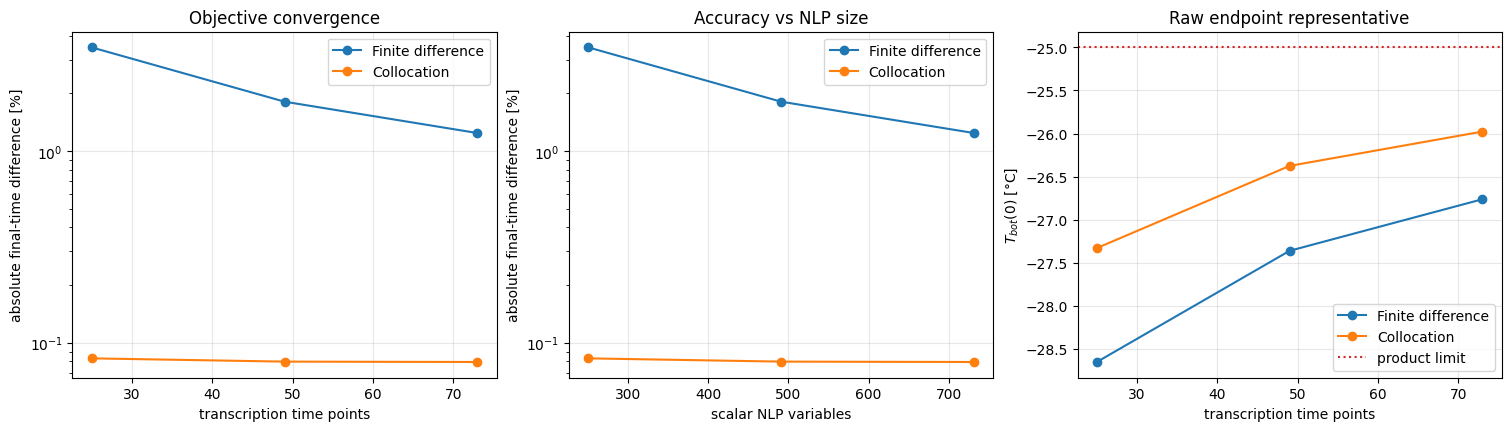

In [11]:
sensitivity_rows = run_discretization_sensitivity(
    nominal.a1,
    nominal.kc,
    nominal.scipy_trajectory,
    point_budgets=sensitivity_point_budgets,
    ncp=ncp,
    final_dried_fraction=final_dried_fraction,
)

print(
    f"{'method':>20} {'nfe':>6} {'points':>7} "
    f"{'variables':>10} {'constraints':>12} {'t1 [h]':>9} "
    f"{'Tbot(0) [°C]':>14} {'objective gap [%]':>18} "
    f"{'wall [s]':>10} {'max residual':>14}"
)
for row in sensitivity_rows:
    print(
        f"{row['method']:>20} {row['nfe']:6d} "
        f"{row['n_time_points']:7d} {row['n_variables']:10d} "
        f"{row['n_constraints']:12d} {row['first_positive_time_hr']:9.4f} "
        f"{row['initial_product_temperature_c']:14.3f} "
        f"{row['objective_gap_percent']:18.3f} "
        f"{row['wall_time_s']:10.3f} "
        f"{row['max_constraint_violation']:14.3e}"
    )

fig, axes = plt.subplots(
    1, 3, figsize=(15, 4.2), layout="constrained"
)
for method, label in [
    ("finite_difference", "Finite difference"),
    ("collocation", "Collocation"),
]:
    rows = [row for row in sensitivity_rows if row["method"] == method]
    error = [
        max(abs(row["objective_gap_percent"]), 1.0e-6)
        for row in rows
    ]
    axes[0].plot(
        [row["n_time_points"] for row in rows],
        error,
        marker="o",
        label=label,
    )
    axes[1].plot(
        [row["n_variables"] for row in rows],
        error,
        marker="o",
        label=label,
    )
    axes[2].plot(
        [row["n_time_points"] for row in rows],
        [row["initial_product_temperature_c"] for row in rows],
        marker="o",
        label=label,
    )
axes[0].set(
    xlabel="transcription time points",
    ylabel="absolute final-time difference [%]",
    title="Objective convergence",
)
axes[1].set(
    xlabel="scalar NLP variables",
    ylabel="absolute final-time difference [%]",
    title="Accuracy vs NLP size",
)
axes[2].axhline(-25.0, color="tab:red", linestyle=":", label="product limit")
axes[2].set(
    xlabel="transcription time points",
    ylabel="$T_{bot}(0)$ [°C]",
    title="Raw endpoint representative",
)
for ax in axes[:2]:
    ax.set_yscale("log")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

## Rate-unlimited operating policy

All three results retain the legacy seven-column output shape. Because neither exact-comparison workflow includes actuator dynamics, the clearest common independent variable is drying progress, not clock time. The following plot therefore presents the controls and algebraic state as an idealized policy against percent dried.

For each DAE curve only, the isolated zero-measure endpoint is omitted from this policy visualization. The raw endpoint remains in the numerical results and in all acceptance checks above; it is not smoothed or overwritten. This avoids drawing a straight time-domain segment from an endpoint representative to a distant first transcription point and mistaking that segment for physical actuator or thermal dynamics. The pressure and constrained-temperature axes use physical tolerances rather than magnifying solver residuals of order $10^{-5}$ mTorr or $10^{-7}\,^{\circ}$C.

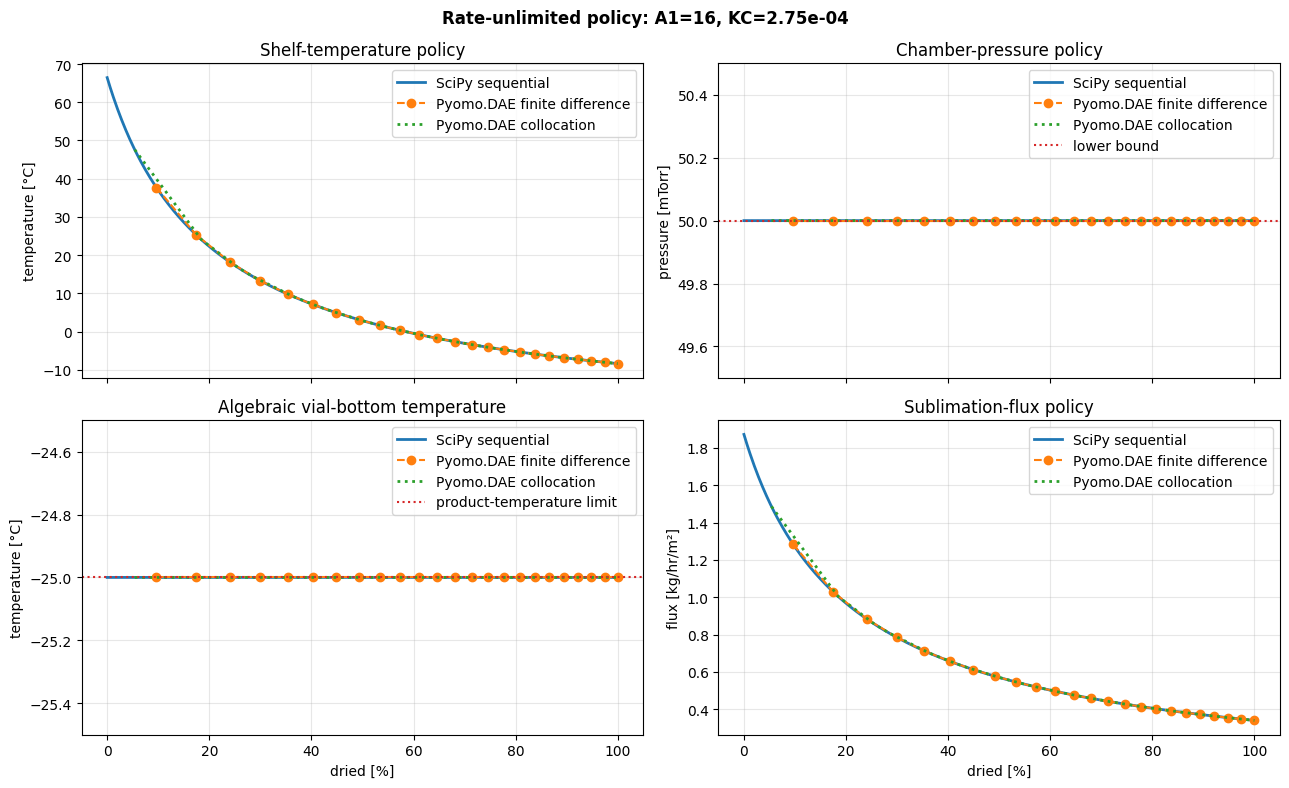

In [12]:
scipy_table = nominal.scipy_trajectory
finite_difference_table = nominal.finite_difference_trajectory
collocation_table = nominal.collocation_trajectory

policy_tables = [
    (scipy_table, "SciPy sequential", {"linewidth": 2.0}),
    (
        finite_difference_table[1:],
        "Pyomo.DAE finite difference",
        {"linestyle": "--", "marker": "o"},
    ),
    (
        collocation_table[1:],
        "Pyomo.DAE collocation",
        {"linestyle": ":", "linewidth": 2.0},
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for table, label, style in policy_tables:
    progress = table[:, 6]
    axes[0, 0].plot(progress, table[:, 3], label=label, **style)
    axes[0, 1].plot(progress, table[:, 4], label=label, **style)
    axes[1, 0].plot(progress, table[:, 2], label=label, **style)
    axes[1, 1].plot(progress, table[:, 5], label=label, **style)

axes[0, 0].set(title="Shelf-temperature policy", ylabel="temperature [°C]")
axes[0, 1].set(title="Chamber-pressure policy", ylabel="pressure [mTorr]")
axes[0, 1].axhline(50.0, color="tab:red", linestyle=":", label="lower bound")
axes[0, 1].set_ylim(49.5, 50.5)
axes[0, 1].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[1, 0].set(
    title="Algebraic vial-bottom temperature",
    xlabel="dried [%]",
    ylabel="temperature [°C]",
)
axes[1, 0].axhline(
    -25.0,
    color="tab:red",
    linestyle=":",
    label="product-temperature limit",
)
axes[1, 0].set_ylim(-25.5, -24.5)
axes[1, 0].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[1, 1].set(
    title="Sublimation-flux policy",
    xlabel="dried [%]",
    ylabel="flux [kg/hr/m²]",
)
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(
    f"Rate-unlimited policy: A1={nominal.a1:g}, KC={nominal.kc:.2e}",
    fontweight="bold",
)
fig.tight_layout()
plt.show()

## Why is optimized pressure constant?

Pressure is released in every run above. A constant profile can still be the optimum when a bound is active over the whole state path. To distinguish that result from an accidentally fixed variable, the next diagnostic re-solves the nominal collocation model while moving only the allowed pressure lower bound. If pressure is genuinely free and lower-bound limited, the realized minimum pressure should follow the new bound and completion time should worsen monotonically as that bound rises.

  P lower bound [Torr]    realized min [Torr]     time [h]
                 0.050                  0.050      10.7608
                 0.075                  0.075      11.4365
                 0.100                  0.100      12.2024
                 0.150                  0.150      14.0877
                 0.200                  0.200      16.6591


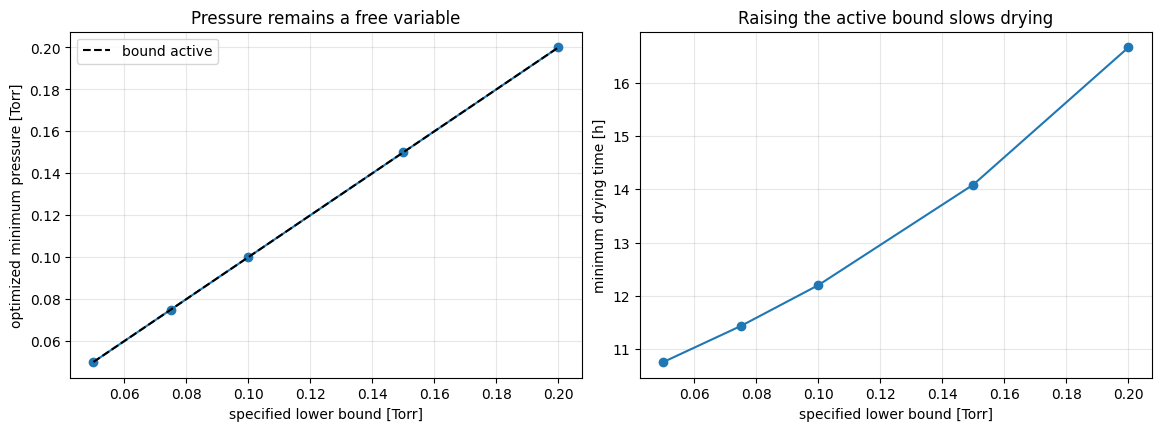

In [13]:
pressure_bound_rows = []
for lower_bound in pressure_lower_bound_values_torr:
    run = run_pyomo_dae(
        nominal.a1,
        nominal.kc,
        discretization="collocation",
        nfe=collocation_nfe,
        ncp=ncp,
        final_dried_fraction=final_dried_fraction,
        pressure_bounds=(float(lower_bound), 0.5),
    )
    assert run.success, (run.solver_status, run.termination_condition)
    realized_minimum = float(np.min(run.trajectory[:, 4]) / 1000.0)
    assert np.isclose(realized_minimum, lower_bound, atol=1.0e-4)
    pressure_bound_rows.append(
        {
            "lower_bound_torr": float(lower_bound),
            "realized_minimum_torr": realized_minimum,
            "objective_time_hr": run.objective_time_hr,
        }
    )

objective_times = [row["objective_time_hr"] for row in pressure_bound_rows]
assert np.all(np.diff(objective_times) >= -constraint_tolerance)

print(f"{'P lower bound [Torr]':>22} {'realized min [Torr]':>22} {'time [h]':>12}")
for row in pressure_bound_rows:
    print(
        f"{row['lower_bound_torr']:22.3f} "
        f"{row['realized_minimum_torr']:22.3f} "
        f"{row['objective_time_hr']:12.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
axes[0].plot(
    [row["lower_bound_torr"] for row in pressure_bound_rows],
    [row["realized_minimum_torr"] for row in pressure_bound_rows],
    marker="o",
)
bound_range = [
    min(pressure_lower_bound_values_torr),
    max(pressure_lower_bound_values_torr),
]
axes[0].plot(
    bound_range,
    bound_range,
    color="black",
    linestyle="--",
    label="bound active",
)
axes[0].set(
    xlabel="specified lower bound [Torr]",
    ylabel="optimized minimum pressure [Torr]",
    title="Pressure remains a free variable",
)
axes[0].legend()
axes[1].plot(
    [row["lower_bound_torr"] for row in pressure_bound_rows],
    objective_times,
    marker="o",
)
axes[1].set(
    xlabel="specified lower bound [Torr]",
    ylabel="minimum drying time [h]",
    title="Raising the active bound slows drying",
)
for ax in axes:
    ax.grid(alpha=0.3)
plt.show()

## Separate rate-limited implementability extension

The exact comparison above deliberately has no actuator memory. Here we solve a separate Pyomo problem with $P_{ch}(0)=150$ mTorr, $T_{sh}(0)=-35\,^{\circ}$C, and nodal movement limits of 0.6 Torr/hr and 60 °C/hr. Both DAE transformations receive the same number of transcription points and the same constraints.

The current sequential SciPy optimizer cannot impose constraints linking controls at successive process states, so it is not included in this extension. Comparing it anyway would no longer be an equivalent-objective experiment. The extension removes instantaneous control jumps at the transcription nodes, but the temperature equations are still quasi-steady algebraic balances: it does not add shelf, vial, or product thermal capacitance.

In [14]:
implementability_fd_nfe, implementability_collocation_nfe = (
    matched_nfe_for_point_budget(implementability_point_budget, ncp)
)
implementability_runs = {}
for method, nfe in (
    ("finite_difference", implementability_fd_nfe),
    ("collocation", implementability_collocation_nfe),
):
    run = run_pyomo_dae(
        nominal.a1,
        nominal.kc,
        discretization=method,
        nfe=nfe,
        ncp=ncp,
        final_dried_fraction=final_dried_fraction,
        initial_pressure=initial_pressure_torr,
        initial_shelf_temperature=initial_shelf_temperature_c,
        pressure_ramp_rate=pressure_ramp_rate_torr_hr,
        shelf_temperature_ramp_rate=shelf_temperature_ramp_rate_c_hr,
    )
    assert run.success, (method, run.solver_status, run.termination_condition)
    table = run.trajectory
    diagnostics = trajectory_constraint_diagnostics(
        table, comparison_inputs(nominal.a1, nominal.kc)
    )
    time_steps = np.diff(table[:, 0])
    observed_pressure_rate = float(
        np.max(np.abs(np.diff(table[:, 4] / 1000.0)) / time_steps)
    )
    observed_shelf_rate = float(
        np.max(np.abs(np.diff(table[:, 3])) / time_steps)
    )
    assert np.isclose(table[0, 4] / 1000.0, initial_pressure_torr, atol=1.0e-6)
    assert np.isclose(table[0, 3], initial_shelf_temperature_c, atol=1.0e-6)
    assert observed_pressure_rate <= pressure_ramp_rate_torr_hr + 1.0e-4
    assert observed_shelf_rate <= shelf_temperature_ramp_rate_c_hr + 1.0e-4
    assert diagnostics["product_temperature_violation_c"] <= constraint_tolerance
    assert diagnostics["minimum_equipment_margin_kg_hr"] >= -1.0e-6
    implementability_runs[method] = {
        "run": run,
        "diagnostics": diagnostics,
        "maximum_pressure_rate_torr_hr": observed_pressure_rate,
        "maximum_shelf_rate_c_hr": observed_shelf_rate,
    }

print(
    f"{'method':>20} {'points':>8} {'time [h]':>12} "
    f"{'P range [mTorr]':>22} {'max |dP/dt|':>13} {'max |dTsh/dt|':>15}"
)
for method, result in implementability_runs.items():
    run = result["run"]
    table = run.trajectory
    pressure_range = f"{np.min(table[:, 4]):.1f}–{np.max(table[:, 4]):.1f}"
    print(
        f"{method:>20} {run.n_time_points:8d} {run.objective_time_hr:12.4f} "
        f"{pressure_range:>22} "
        f"{result['maximum_pressure_rate_torr_hr']:13.3f} "
        f"{result['maximum_shelf_rate_c_hr']:15.3f}"
    )

              method   points     time [h]        P range [mTorr]   max |dP/dt|   max |dTsh/dt|
   finite_difference       97      11.3546             50.0–252.7         0.600          60.000
         collocation       97      11.3306             50.0–261.0         0.600          60.000


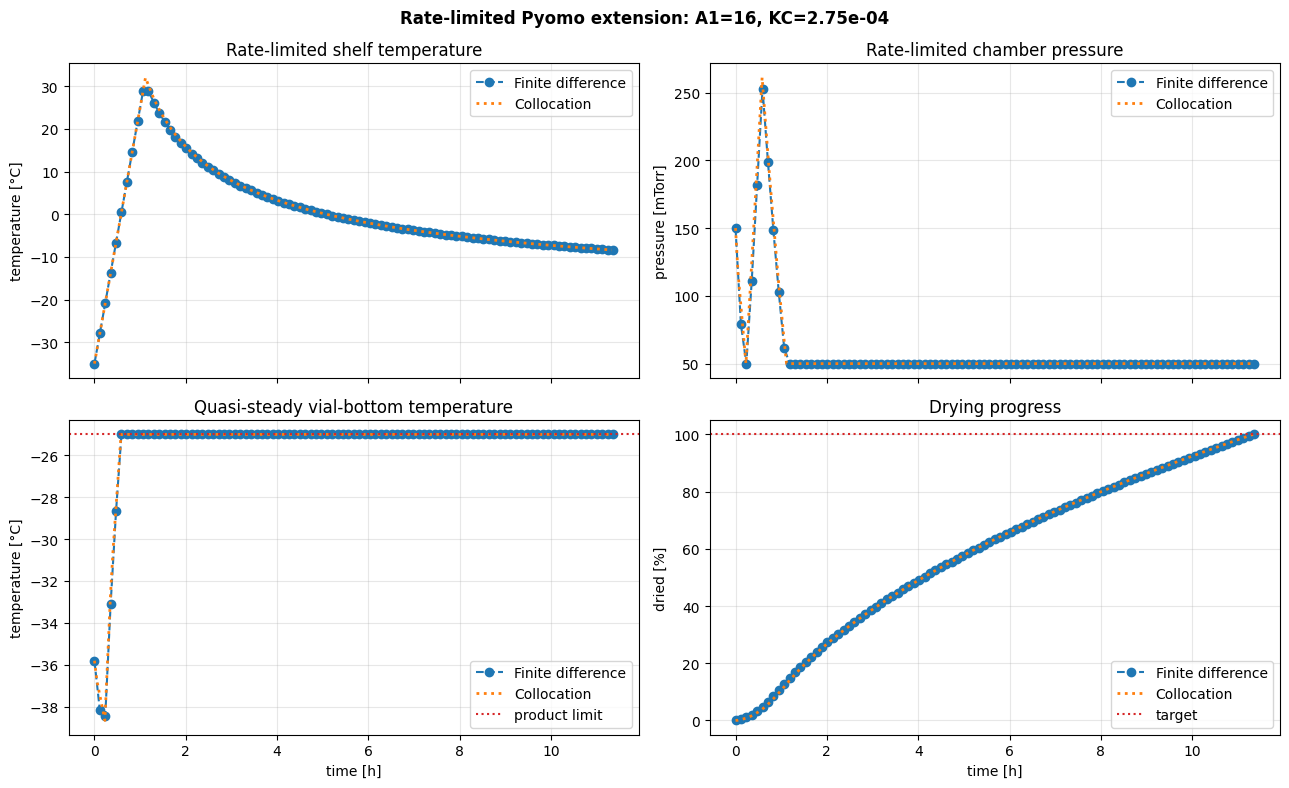

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for method, label, style in (
    ("finite_difference", "Finite difference", {"linestyle": "--", "marker": "o"}),
    ("collocation", "Collocation", {"linestyle": ":", "linewidth": 2.0}),
):
    table = implementability_runs[method]["run"].trajectory
    axes[0, 0].plot(table[:, 0], table[:, 3], label=label, **style)
    axes[0, 1].plot(table[:, 0], table[:, 4], label=label, **style)
    axes[1, 0].plot(table[:, 0], table[:, 2], label=label, **style)
    axes[1, 1].plot(table[:, 0], table[:, 6], label=label, **style)

axes[0, 0].set(title="Rate-limited shelf temperature", ylabel="temperature [°C]")
axes[0, 1].set(title="Rate-limited chamber pressure", ylabel="pressure [mTorr]")
axes[1, 0].set(
    title="Quasi-steady vial-bottom temperature",
    xlabel="time [h]",
    ylabel="temperature [°C]",
)
axes[1, 0].axhline(-25.0, color="tab:red", linestyle=":", label="product limit")
axes[1, 1].set(title="Drying progress", xlabel="time [h]", ylabel="dried [%]")
axes[1, 1].axhline(
    100.0 * final_dried_fraction,
    color="tab:red",
    linestyle=":",
    label="target",
)
for ax in axes.flat:
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(
    f"Rate-limited Pyomo extension: A1={nominal.a1:g}, KC={nominal.kc:.2e}",
    fontweight="bold",
)
fig.tight_layout()
plt.show()

The pressure profiles are now nonconstant because the fixed initial pressure and finite movement rates create an intertemporal trade-off among pressure-dependent heat transfer, sublimation driving force, and approach to the active product-temperature limit. The four panels keep the two controls, constrained vial-bottom temperature, and progress visually separate—there are no faded shelf-temperature curves on the $T_{bot}$ panel.

Any rapid $T_{bot}$ response that remains is the response of the quasi-steady algebraic model, not a prediction of thermal inertia. Modeling thermal lag would require additional differential states and independently validated capacitance parameters.

## Optionally save a compact reproduction record

Generated experiment outputs belong under `benchmarks/results/`, which is ignored by default. The JSON file contains environment, scalar summaries, pressure-bound sensitivity, and rate-limit assumptions; the compressed NumPy archive retains the exact-comparison and rate-limited trajectories used for the plots.

In [16]:
if save_results:
    destination = Path(results_dir)
    destination.mkdir(parents=True, exist_ok=True)
    summaries = [
        {
            "A1": case.a1,
            "KC": case.kc,
            "scipy_objective_time_hr": case.scipy_objective_time_hr,
            "finite_difference_objective_time_hr": (
                case.finite_difference_objective_time_hr
            ),
            "collocation_objective_time_hr": (
                case.collocation_objective_time_hr
            ),
            "finite_difference_objective_gap_percent": (
                case.finite_difference_objective_gap_percent
            ),
            "collocation_objective_gap_percent": (
                case.collocation_objective_gap_percent
            ),
            "scipy_wall_times_s": list(case.scipy_wall_times_s),
            "finite_difference_wall_times_s": list(
                case.finite_difference_wall_times_s
            ),
            "collocation_wall_times_s": list(case.collocation_wall_times_s),
            "finite_difference_speedup": case.finite_difference_speedup,
            "collocation_speedup": case.collocation_speedup,
            "finite_difference_n_variables": case.finite_difference_n_variables,
            "finite_difference_n_constraints": case.finite_difference_n_constraints,
            "collocation_n_variables": case.collocation_n_variables,
            "collocation_n_constraints": case.collocation_n_constraints,
            "finite_difference_max_constraint_violation": (
                case.finite_difference_max_constraint_violation
            ),
            "collocation_max_constraint_violation": (
                case.collocation_max_constraint_violation
            ),
        }
        for case in comparisons
    ]
    payload = {
        "environment": environment,
        "parameters": {
            "scipy_dt": scipy_dt,
            "scipy_dt_values": scipy_dt_values,
            "point_budget": point_budget,
            "finite_difference_nfe": finite_difference_nfe,
            "collocation_nfe": collocation_nfe,
            "ncp": ncp,
            "final_dried_fraction": final_dried_fraction,
            "timing_repeats": timing_repeats,
            "implementability_point_budget": implementability_point_budget,
            "initial_pressure_torr": initial_pressure_torr,
            "initial_shelf_temperature_c": initial_shelf_temperature_c,
            "pressure_ramp_rate_torr_hr": pressure_ramp_rate_torr_hr,
            "shelf_temperature_ramp_rate_c_hr": shelf_temperature_ramp_rate_c_hr,
        },
        "cases": summaries,
        "trajectory_diagnostics": diagnostic_rows,
        "scipy_convergence": scipy_convergence_rows,
        "discretization_sensitivity": sensitivity_rows,
        "pressure_bound_sensitivity": pressure_bound_rows,
    }
    (destination / "summary.json").write_text(
        json.dumps(payload, indent=2) + "\n"
    )
    trajectories = {}
    for case in comparisons:
        key = (
            f"A1_{case.a1:g}_KC_{case.kc:.2e}"
            .replace(".", "p")
            .replace("-", "m")
        )
        trajectories[f"{key}_scipy"] = case.scipy_trajectory
        trajectories[f"{key}_finite_difference"] = case.finite_difference_trajectory
        trajectories[f"{key}_collocation"] = case.collocation_trajectory
    for method, result in implementability_runs.items():
        trajectories[f"nominal_rate_limited_{method}"] = result["run"].trajectory
    np.savez_compressed(destination / "trajectories.npz", **trajectories)
    print(f"Saved reproduction record under {destination}")
else:
    print("Set save_results=True to write JSON and NPZ outputs.")

Set save_results=True to write JSON and NPZ outputs.


## Interpretation boundaries

This notebook reproduces the scientific question with current code rather than preserving historical outputs as golden numbers. Agreement in the exact comparison is judged using the common final-time objective, SciPy-step and DAE-mesh convergence, independently evaluated trajectory constraints, and current model residuals together. Exact speedups are machine-dependent.

In the committed run, 25-point collocation is within the resolution of the finest sequential SciPy reference, while backward Euler shows the expected first-order refinement trend. The raw DAE endpoint-temperature offset shrinks as the first positive transcription time approaches zero. It is therefore not evidence of a modeled thermal excursion.

The repeated columns across $K_C$ and constant pressure in the exact comparison come from a transparent active set: pressure follows its lower bound, the product-temperature limit controls sublimation, shelf-temperature bounds remain inactive, and equipment capacity retains positive margin. Re-solving with successively higher pressure lower bounds makes the realized pressure follow each new bound and increases minimum drying time, confirming that pressure was free rather than fixed.

The rate-limited extension produces nonconstant pressure and rate-bounded nodal control movement from the stated initial conditions. It is intentionally not included in the SciPy/Pyomo objective-gap heatmaps because adding intertemporal constraints changes the problem and the current sequential SciPy API cannot express them. Even this extension retains quasi-steady algebraic temperatures; a physically predictive thermal transient would require new differential states and validated capacitance parameters.